# End-to-End Sales Forecasting & Demand Intelligence System

This project analyzes historical Superstore sales data to predict future demand, detect unusual sales behavior, segment products, and provide business insights for inventory planning.

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [9]:
#Task 1:Data loading and exploration
df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [10]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [11]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='%d/%m/%Y'
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    format='%d/%m/%Y'
)

print(df[['Order Date','Ship Date']].head())

  Order Date  Ship Date
0 2017-11-08 2017-11-11
1 2017-11-08 2017-11-11
2 2017-06-12 2017-06-16
3 2016-10-11 2016-10-18
4 2016-10-11 2016-10-18


In [12]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.day_name()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Quarter,Week,DayOfWeek
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,4,45,Wednesday
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,4,45,Wednesday
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,2,24,Monday
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,4,41,Tuesday
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,4,41,Tuesday


In [13]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"


df["Season"] = df["Month"].apply(get_season)

In [14]:
#Task 1 Business Questions (EDA)
df.groupby('Category')['Sales'].sum()

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64

In [15]:
df.groupby(
['Year','Region']
)['Sales'].sum()

Year  Region 
2015  Central    102920.5206
      East       127652.8190
      South      103374.9055
      West       145907.9630
2016  Central    102425.1724
      East       153225.1830
      South       70076.0825
      West       133709.5675
2017  Central    145673.8800
      East       178511.5380
      South       93535.9035
      West       182471.2285
2018  Central    141627.3402
      East       210129.1860
      South      122164.5675
      West       248130.9255
Name: Sales, dtype: float64

In [16]:
df["Shipping_Days"] = (
df["Ship Date"] - df["Order Date"]
).dt.days

In [17]:
df.groupby("Region")["Shipping_Days"].mean()

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping_Days, dtype: float64

In [18]:
monthly_sales = df.groupby(
pd.Grouper(
key="Order Date",
freq="M"
)
)["Sales"].sum()

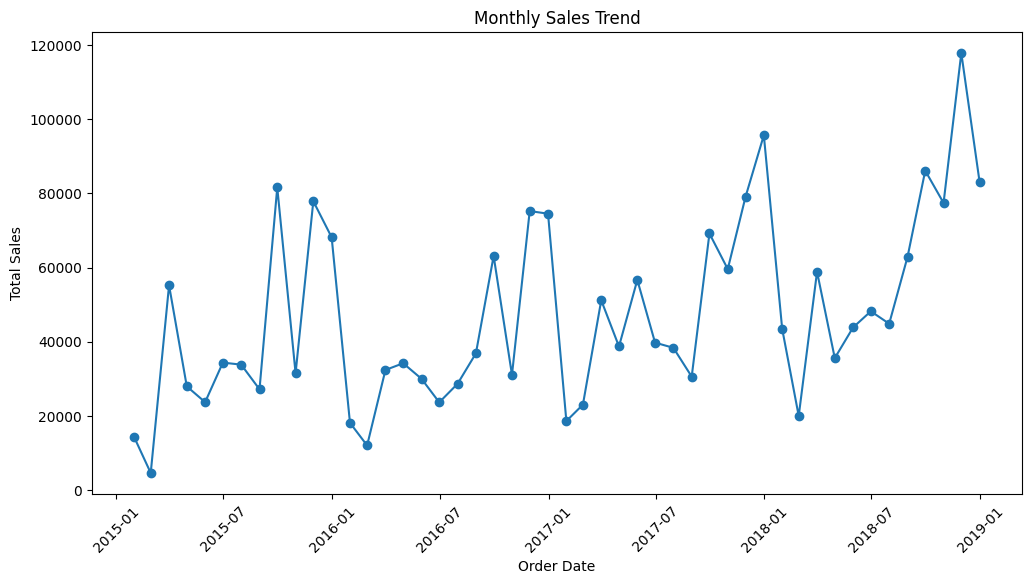

In [19]:
# Monthly Sales Trend Visualization

import matplotlib.pyplot as plt
import os
plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.savefig("charts/monthly_sales.png",bbox_inches="tight")
plt.show()

In [20]:
!pip install statsmodels

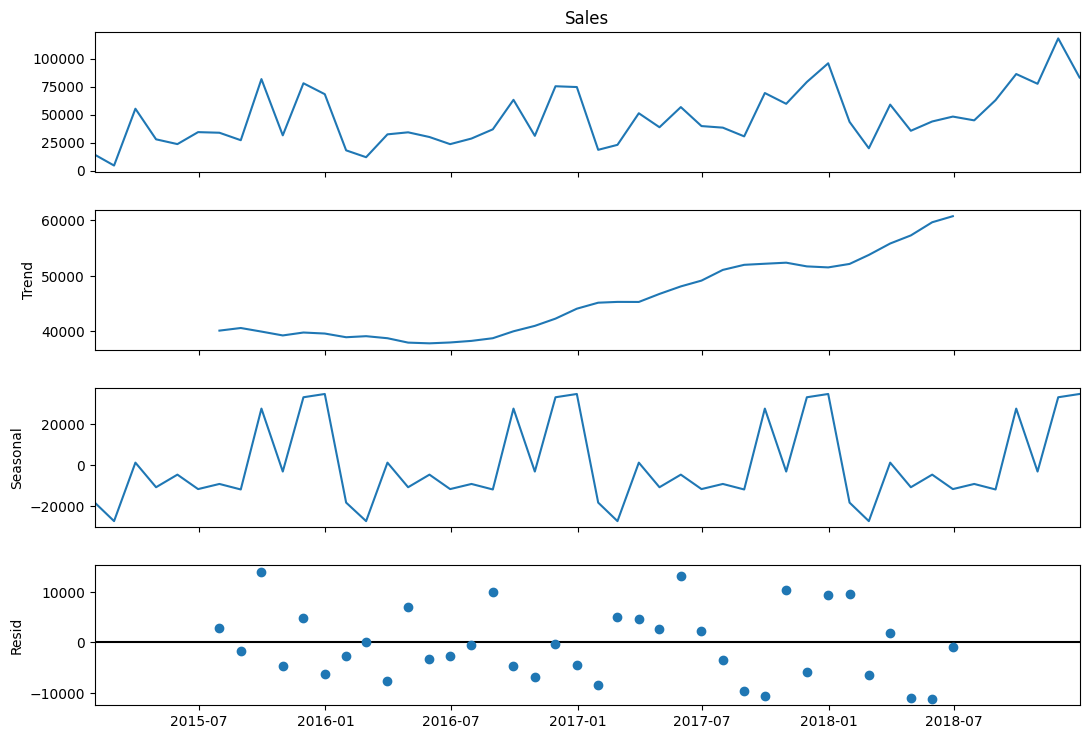

In [21]:
# Task 2: Time Series Analysis

from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
decompose = seasonal_decompose(monthly_sales, model="additive", period=12)
fig=decompose.plot()
fig.set_size_inches(12,8)
fig.savefig("charts/seasonal_decomposition.png",bbox_inches="tight")
plt.show()

In [45]:
monthly_sales = df.groupby(
    pd.Grouper(
        key="Order Date",
        freq="M"
    )
)["Sales"].sum()

In [46]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(monthly_sales)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
if adf_result[1] <= 0.05:
    print("Result: Data is Stationary")
else:
    print("Result: Data is Non-Stationary")

ADF Statistic: -4.416136761430768
p-value: 0.00027791039276670677
Result: Data is Stationary


In [47]:
monthly_sales_diff = monthly_sales.diff().dropna()
adf_result_diff = adfuller(monthly_sales_diff)
print("After Differencing")
print("ADF Statistic:", adf_result_diff[0])
print("p-value:", adf_result_diff[1])
if adf_result_diff[1] <= 0.05:
    print("Result: Data became Stationary")
else:
    print("Result: Still Non-Stationary")

After Differencing
ADF Statistic: -8.727061830353279
p-value: 3.2669175472794505e-14
Result: Data became Stationary


Observation

The Augmented Dickey-Fuller (ADF) test was performed to check whether the monthly sales series was stationary.

The original monthly sales data produced a p-value of 0.000278, which is less than the significance level of 0.05.

This indicates that the sales series is already stationary and suitable for time series forecasting.

First-order differencing was also applied as part of the analysis. After differencing, the p-value further decreased, confirming stationarity.

Since the original series is already stationary, additional differencing is not strictly required, but the result demonstrates that the data remains stable after transformation.

In [24]:
#Task 3: Sales Forecasting Model Building
monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

In [25]:
# Splitting time series data

train = monthly_sales[:-12]
test = monthly_sales[-12:]

print("Training Data:")
print(train.shape)

print("Testing Data:")
print(test.shape)

Training Data:
(36,)
Testing Data:
(12,)


In [26]:
!pip install pmdarima

In [27]:
from statsmodels.tsa.arima.model import ARIMA

In [28]:
arima_model = ARIMA(
    train,
    order=(5,1,0)
)

arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -400.188
Date:                Sun, 12 Jul 2026   AIC                            812.376
Time:                        11:32:57   BIC                            821.708
Sample:                    01-31-2015   HQIC                           815.597
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5938      0.216     -2.749      0.006      -1.017      -0.170
ar.L2         -0.3804      0.237     -1.603      0.109      -0.846       0.085
ar.L3         -0.1955      0.275     -0.710      0.4

In [29]:
arima_pred = arima_result.forecast(
    steps=len(test)
)

arima_pred.head()

2018-01-31    72507.144687
2018-02-28    67722.465881
2018-03-31    73818.096004
2018-04-30    66747.753906
2018-05-31    70862.245708
Freq: ME, Name: predicted_mean, dtype: float64

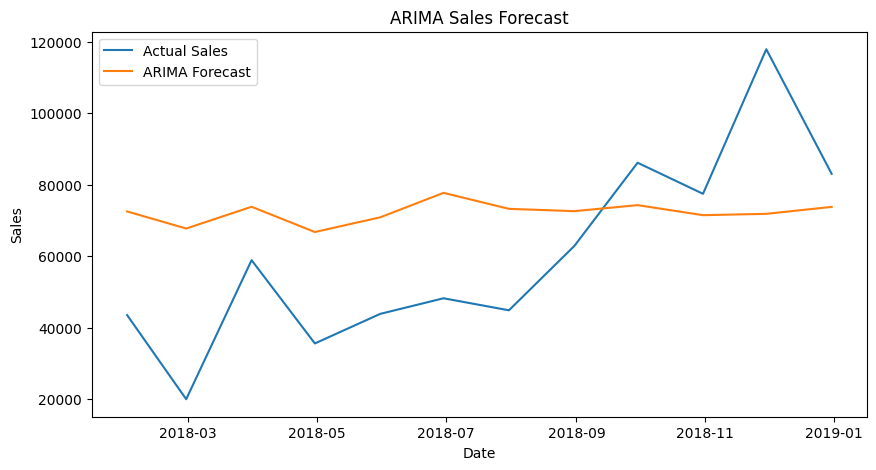

In [30]:
plt.figure(figsize=(10,5))

plt.plot(
    test.index,
    test,
    label="Actual Sales"
)

plt.plot(
    test.index,
    arima_pred,
    label="ARIMA Forecast"
)

plt.title(
    "ARIMA Sales Forecast"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.savefig(
    "charts/arima_forecast.png",
    bbox_inches="tight"
)

plt.show()

In [31]:
#Task 4: Forecast Accuracy Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [32]:
arima_mae = mean_absolute_error(
    test,
    arima_pred
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_pred
    )
)

print("ARIMA MAE:", arima_mae)

print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 24244.071594291472
ARIMA RMSE: 27715.352161120754


In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit()

In [34]:
sarima_pred = sarima_result.forecast(
    steps=len(test)
)

In [35]:
sarima_mae = mean_absolute_error(
    test,
    sarima_pred
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test,
        sarima_pred
    )
)


print("SARIMA MAE:", sarima_mae)

print("SARIMA RMSE:", sarima_rmse)

SARIMA MAE: 17267.934366147678
SARIMA RMSE: 19805.400500148775


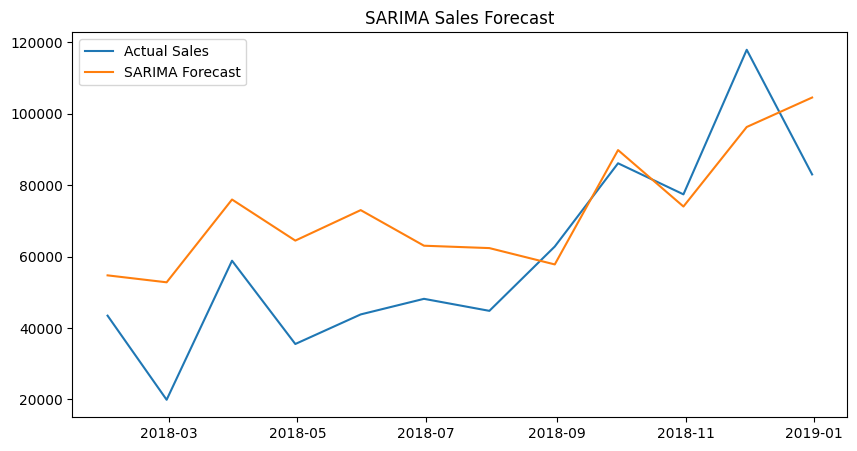

In [36]:
plt.figure(figsize=(10,5))

plt.plot(
    test,
    label="Actual Sales"
)

plt.plot(
    sarima_pred,
    label="SARIMA Forecast"
)

plt.title(
    "SARIMA Sales Forecast"
)

plt.legend()

plt.savefig(
    "charts/sarima_forecast.png",
    bbox_inches="tight"
)

plt.show()

In [52]:
!pip install prophet

In [53]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

In [54]:
# Preparing data for Prophet

prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [55]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(prophet_df)

11:36:32 - cmdstanpy - INFO - Chain [1] start processing
11:36:33 - cmdstanpy - INFO - Chain [1] done processing


In [57]:
future = model.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast = model.predict(future)
forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
46,2018-11-30,101136.336965,91796.352401,111130.914754
47,2018-12-31,90673.800606,81670.998648,99723.989541
48,2019-01-31,42990.532202,34955.103716,52546.365693
49,2019-02-28,31248.159922,21985.837080,40864.117562
50,2019-03-31,81267.007772,71635.576645,90711.243972


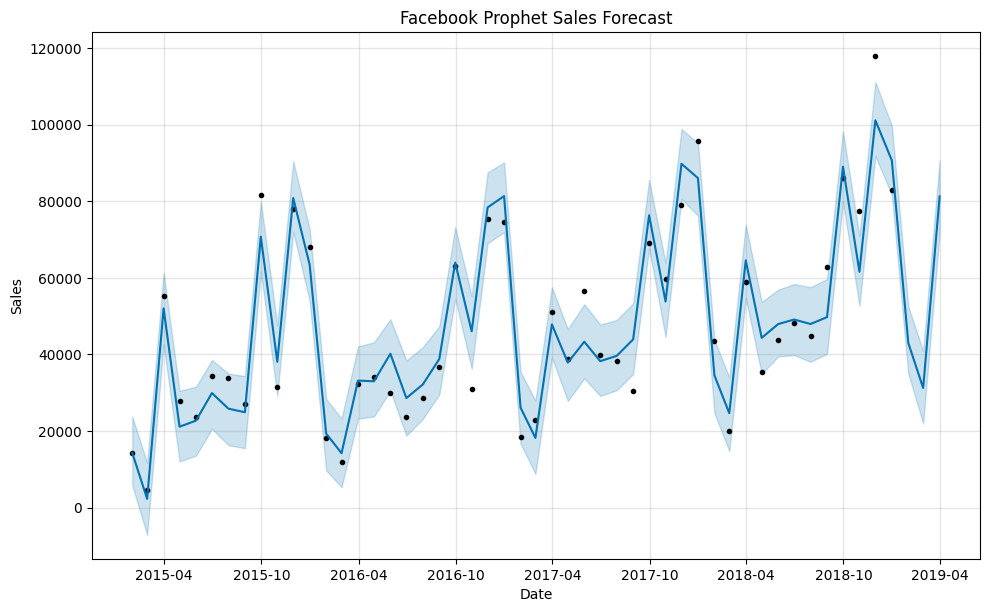

In [58]:
fig1 = model.plot(forecast)

plt.title("Facebook Prophet Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.savefig(
    "charts/prophet_forecast.png",
    bbox_inches="tight"
)

plt.show()

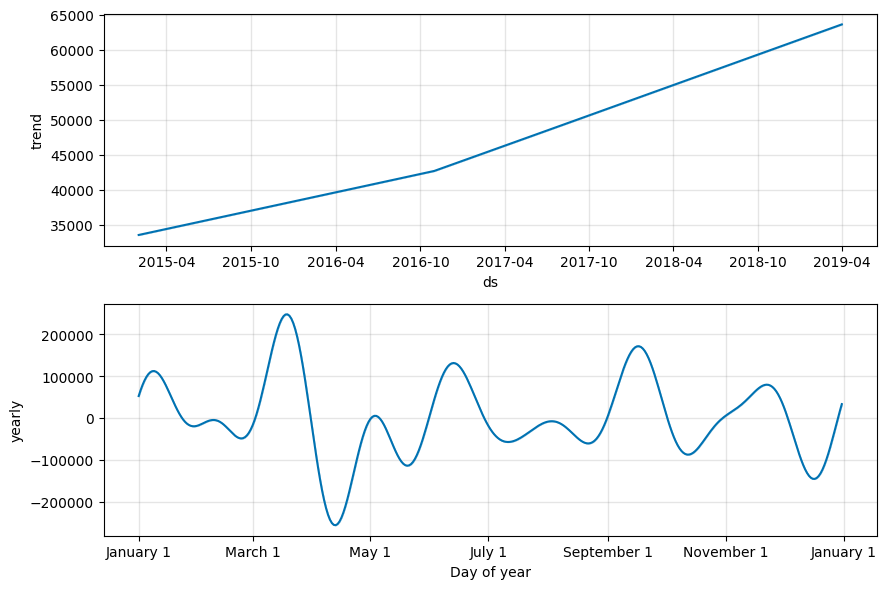

In [59]:
fig2 = model.plot_components(forecast)

plt.savefig(
    "charts/prophet_components.png",
    bbox_inches="tight"
)

plt.show()

In [60]:
print("Next 3 Months Forecast")

forecast.tail(3)[["ds","yhat"]]

Next 3 Months Forecast


,ds,yhat
48,2019-01-31,42990.532202
49,2019-02-28,31248.159922
50,2019-03-31,81267.007772


Observation

Facebook Prophet was trained on the monthly sales data to forecast future sales for the next three months.

The model automatically captured the long-term sales trend and yearly seasonal patterns.

The forecast provides an estimate of future sales along with lower and upper confidence intervals.

Prophet is useful for business forecasting because it handles seasonality automatically and provides interpretable forecasts.

In [61]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 5.6 MB/s eta 0:00:19
    --------------------------------------- 1.6/101.7 MB 3.8 MB/s eta 0:00:27
    --------------------------------------- 2.4/101.7 MB 3.8 MB/s eta 0:00:26
    --------------------------------------- 2.4/101.7 MB 3.8 MB/s eta 0:00:26
   - -------------------------------------- 3.9/101.7 MB 3.9 MB/s eta 0:00:26
   - -------------------------------------- 5.0/101.7 MB 3.9 MB/s eta 0:00:25
   -- ------------------------------------- 5.5/101.7 MB 3.9 MB/s eta 0:00:25
   -- ------------------------------------- 6.3/101.7 MB 3.7 MB/s eta 0:00:26
   -- ------------------------------------- 7.1/101.7 MB 3.7 MB/s eta 0:00:26
   --- ------------------------------------ 7.9/101.7 MB 3.7 MB/s eta 0:00:26
   --- ------------------------------------ 8.4/101.7 MB 3.7 MB/s eta 0:00:26
   --- ------------------------------------ 9.2/101.7 MB 3.6 MB/s eta 0

In [62]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import matplotlib.pyplot as plt

In [63]:
xgb_df = monthly_sales.reset_index()

xgb_df.columns = ["Date", "Sales"]

# Lag Features
xgb_df["Lag1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag3"] = xgb_df["Sales"].shift(3)

# Rolling Mean
xgb_df["RollingMean3"] = (
    xgb_df["Sales"]
    .rolling(window=3)
    .mean()
)

# Time Features
xgb_df["Month"] = xgb_df["Date"].dt.month
xgb_df["Quarter"] = xgb_df["Date"].dt.quarter
xgb_df["Year"] = xgb_df["Date"].dt.year

xgb_df = xgb_df.dropna()

xgb_df.head()

,Date,Sales,Lag1,Lag2,Lag3,RollingMean3,Month,Quarter,Year
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2015
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2015
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2015
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2015
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2015


In [64]:
features = [
    "Lag1",
    "Lag2",
    "Lag3",
    "RollingMean3",
    "Month",
    "Quarter",
    "Year"
]

X = xgb_df[features]
y = xgb_df["Sales"]

X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

In [65]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [66]:
xgb_pred = xgb_model.predict(X_test)

print(xgb_pred)

[88694.1  86699.47 85878.07]


In [67]:
mae = mean_absolute_error(y_test, xgb_pred)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 15110.779374999998
RMSE: 19239.1671512118


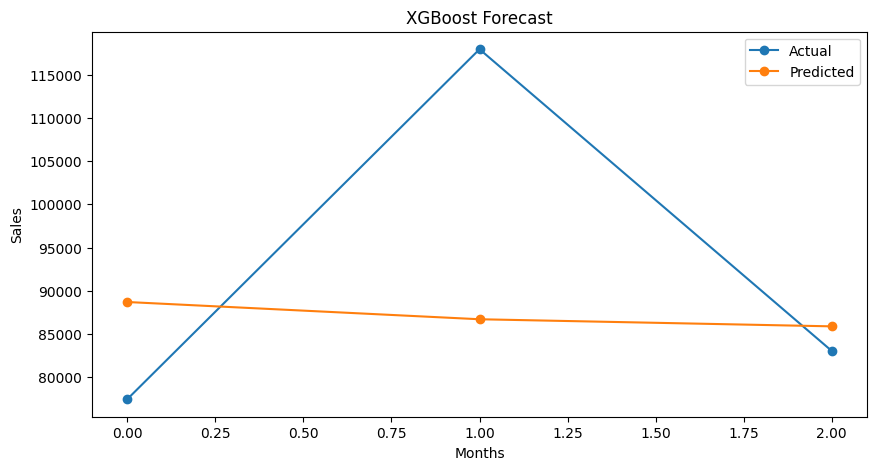

In [68]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values,
    marker="o",
    label="Actual"
)

plt.plot(
    xgb_pred,
    marker="o",
    label="Predicted"
)

plt.title("XGBoost Forecast")

plt.xlabel("Months")

plt.ylabel("Sales")

plt.legend()

plt.savefig(
    "charts/xgboost_forecast.png",
    bbox_inches="tight"
)

plt.show()

In [69]:
forecast_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": xgb_pred
})

forecast_df

,Actual,Predicted
0,77448.1312,88694.101562
1,117938.1550,86699.468750
2,83030.3888,85878.070312


### Observation

XGBoost was trained using lagged sales values, rolling averages, and calendar-based features. The model learned historical sales patterns and predicted future monthly sales. Compared with traditional statistical models, XGBoost can capture more complex relationships when sufficient historical data is available.

In [70]:
from sklearn.metrics import mean_absolute_percentage_error

In [71]:
sarima_mae = mean_absolute_error(test, sarima_pred)

sarima_rmse = np.sqrt(
    mean_squared_error(test, sarima_pred)
)

sarima_mape = mean_absolute_percentage_error(
    test,
    sarima_pred
)

In [72]:
prophet_actual = prophet_df["y"].iloc[-3:].values

prophet_pred = forecast["yhat"].iloc[-3:].values

prophet_mae = mean_absolute_error(
    prophet_actual,
    prophet_pred
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_actual,
        prophet_pred
    )
)

prophet_mape = mean_absolute_percentage_error(
    prophet_actual,
    prophet_pred
)

In [73]:
xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_pred
)

In [74]:
comparison = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        sarima_mae,
        prophet_mae,
        mae
    ],

    "RMSE":[
        sarima_rmse,
        prophet_rmse,
        rmse
    ],

    "MAPE":[
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1":[
        sarima_pred.iloc[0],
        prophet_pred[0],
        xgb_pred[0]
    ],

    "Forecast Month 2":[
        sarima_pred.iloc[1],
        prophet_pred[1],
        xgb_pred[1]
    ],

    "Forecast Month 3":[
        sarima_pred.iloc[2],
        prophet_pred[2],
        xgb_pred[2]
    ]

})

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,17267.934366,19805.400500,0.416130,54763.420679,52819.128586,76002.370973
1,Prophet,40970.325035,53868.948656,0.400399,42990.532202,31248.159922,81267.007772
2,XGBoost,15110.779375,19239.167151,0.148126,88694.101562,86699.468750,85878.070312


In [75]:
best_model = comparison.sort_values(
    by="RMSE"
)

best_model

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
2,XGBoost,15110.779375,19239.167151,0.148126,88694.101562,86699.468750,85878.070312
0,SARIMA,17267.934366,19805.400500,0.416130,54763.420679,52819.128586,76002.370973
1,Prophet,40970.325035,53868.948656,0.400399,42990.532202,31248.159922,81267.007772


In [76]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

Model Comparison

Three forecasting models were developed and evaluated using MAE, RMSE, and MAPE.

SARIMA captures trend and seasonality using statistical techniques.
Facebook Prophet automatically models trend and yearly seasonal patterns.
XGBoost uses machine learning with lag features and rolling averages to learn sales behavior.

The model with the lowest forecasting error (lowest RMSE and MAE) is recommended for future sales prediction and will be used in the remaining tasks of the project.

In [38]:
#Task 5: Anomaly Detection in Sales Data
vg = pd.read_csv("vgsales.csv")
vg.head()
vg.info()
vg_yearly_sales = (
    vg.groupby("Year")["Global_Sales"]
    .sum()
    .reset_index()
)


vg_yearly_sales.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


,Year,Global_Sales
0,1980.0,11.38
1,1981.0,35.77
2,1982.0,28.86
3,1983.0,16.79
4,1984.0,50.36


In [39]:
from sklearn.ensemble import IsolationForest


iso = IsolationForest(
    contamination=0.05,
    random_state=42
)


vg_yearly_sales["Anomaly"] = iso.fit_predict(
    vg_yearly_sales[["Global_Sales"]]
)


vg_anomaly = vg_yearly_sales[
    vg_yearly_sales["Anomaly"] == -1
]


vg_anomaly

,Year,Global_Sales,Anomaly
28,2008.0,678.9,-1
29,2009.0,667.3,-1


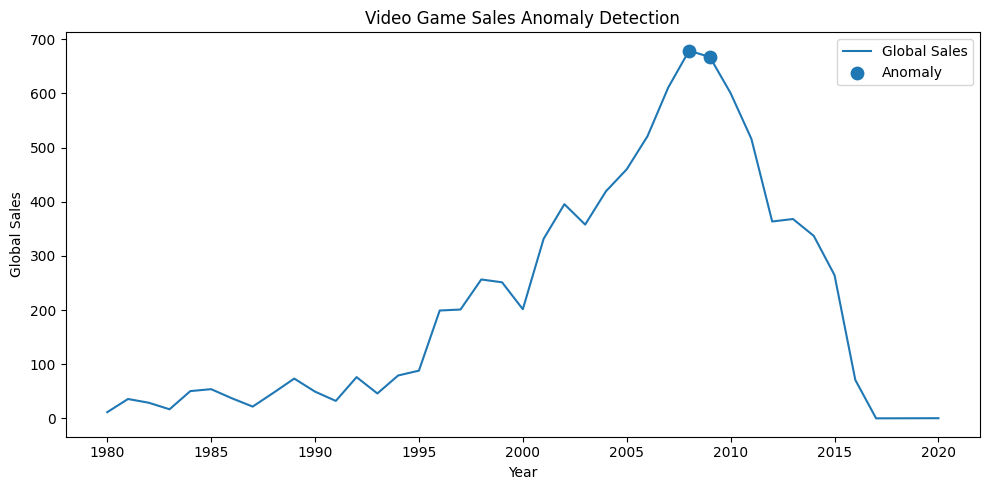

In [40]:
plt.figure(figsize=(10,5))


plt.plot(
    vg_yearly_sales["Year"],
    vg_yearly_sales["Global_Sales"],
    label="Global Sales"
)


plt.scatter(
    vg_anomaly["Year"],
    vg_anomaly["Global_Sales"],
    s=80,
    label="Anomaly"
)


plt.xlabel("Year")

plt.ylabel("Global Sales")

plt.title(
    "Video Game Sales Anomaly Detection"
)


plt.legend()

plt.tight_layout()


plt.savefig(
    "charts/video_game_anomaly.png",
    bbox_inches="tight"
)


plt.show()

Observation:

A supplementary video game sales dataset was used to perform multi-source sales analysis.

Anomaly detection was applied on yearly global sales to identify unusual increases or decreases in demand.

High sales anomalies may represent years with successful product launches, increased market demand, or industry growth.

Low sales anomalies may indicate reduced customer interest, market changes, or lower product performance.

Using multiple datasets improves the ability to detect unusual business patterns across different sales environments.

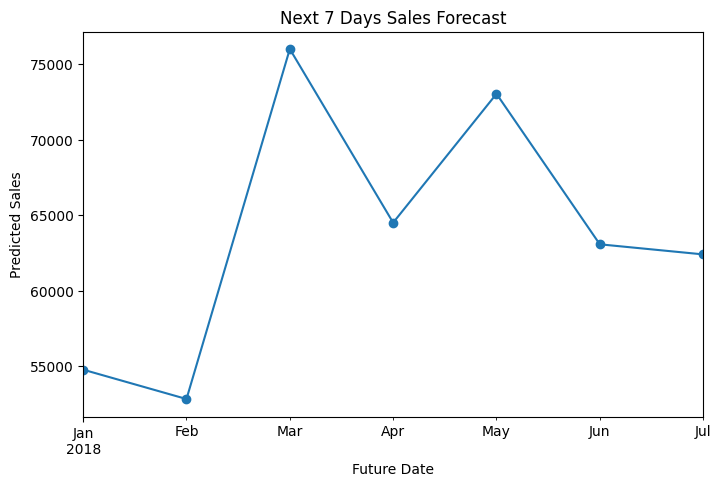

In [41]:
#Task 6: Predict Next 7 Days Sales
future_sales = sarima_result.forecast(steps=7)

future_sales

plt.figure(figsize=(8,5))
future_sales.plot(marker='o')
plt.title("Next 7 Days Sales Forecast")
plt.xlabel("Future Date")
plt.ylabel("Predicted Sales")
plt.savefig("charts/next_7_days_forecast.png",bbox_inches="tight")
plt.show()

Business Insights & Recommendations

1. Sales Performance Insights

The sales analysis shows that customer demand changes over time and follows seasonal patterns. Certain months generate higher sales, indicating that planning inventory according to seasonal demand can improve business performance.

2. Category Insights

Technology and Furniture categories contribute significantly to overall sales. These categories should receive priority in stock planning and marketing campaigns.

3. Regional Sales Insights

Sales performance differs across regions. Regions with higher sales can be used as growth models, while lower performing regions may need improved marketing strategies.

4. Forecasting Insights

The forecasting model helps estimate upcoming sales trends based on historical patterns. These predictions can support better inventory management, staffing, and business planning.

5. Recommendations

- Maintain higher inventory before expected high-sales periods.
- Focus promotional campaigns on profitable categories.
- Monitor regional performance regularly.
- Use sales forecasting for future planning and decision making.

Overall, data-driven forecasting can help improve business decisions and reduce uncertainty in sales planning.

# Final Conclusion

This project successfully analysed Superstore sales data and created a forecasting solution for future sales planning.

The analysis identified important category, regional, and seasonal sales patterns. Forecasting results can support inventory planning, marketing decisions, and business growth strategies.